# Глубинное обучение 1 / Введение в глубинное обучение, ФКН ВШЭ

## Домашнее задание 1. Часть 2: полносвязные нейронные сети. 

### Общая информация

Оценка после штрафа после мягкого дедлайна вычисляется по формуле $M_{\text{penalty}} = M_{\text{full}} \cdot 0.85^{t/1440}$, где $M_{\text{full}}$ — полная оценка за работу без учета штрафа, а $t$ — время в минутах, прошедшее после мягкого дедлайна (округление до двух цифр после запятой). Таким образом, спустя первые сутки после мягкого дедлайна вы не можете получить оценку выше 8.5, а если сдать через четыре дня после мягкого дедлайна, то ваш максимум — 5.22 балла.

### Оценивание и штрафы

Максимально допустимая оценка за работу — 10 баллов. Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

### О задании

В этой части мы будем использовать фреймворк для обучения нейронный сетей, который вы реализовали в первой половине задания. А именно, вам предстоит обучить полносвязную нейронную сеть для предсказания года выпуска песни по ее аудио-признакам. Для этого мы будем использовать [Million Songs Dataset](https://samyzaf.com/ML/song_year/song_year.html). Если по какой-то причине вы не сделали первую половину домашки, то **можете поставить все эксперименты на PyTorch**, но рекомендуется использовать ваши реализации модулей. 

In [1]:
import modules as mm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import clear_output

plt.rcParams.update({'font.size': 16})
sns.set_style('whitegrid')
np.random.seed(0xFA1AFE1)

Начнем с того, что скачаем и загрузим данные:

In [ ]:
!wget -O data.txt.zip https://archive.ics.uci.edu/ml/machine-learning-databases/00203/YearPredictionMSD.txt.zip

In [3]:
df = pd.read_csv('data.txt.zip', header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515340,2006,51.28467,45.88068,22.19582,-5.53319,-3.61835,-16.36914,2.12652,5.18160,-8.66890,...,4.81440,-3.75991,-30.92584,26.33968,-5.03390,21.86037,-142.29410,3.42901,-41.14721,-15.46052
515341,2006,49.87870,37.93125,18.65987,-3.63581,-27.75665,-18.52988,7.76108,3.56109,-2.50351,...,32.38589,-32.75535,-61.05473,56.65182,15.29965,95.88193,-10.63242,12.96552,92.11633,10.88815
515342,2006,45.12852,12.65758,-38.72018,8.80882,-29.29985,-2.28706,-18.40424,-22.28726,-4.52429,...,-18.73598,-71.15954,-123.98443,121.26989,10.89629,34.62409,-248.61020,-6.07171,53.96319,-8.09364
515343,2006,44.16614,32.38368,-3.34971,-2.49165,-19.59278,-18.67098,8.78428,4.02039,-12.01230,...,67.16763,282.77624,-4.63677,144.00125,21.62652,-29.72432,71.47198,20.32240,14.83107,39.74909


Посмотрим на статистики по данным.

In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
count,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,...,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000,515345.000000
mean,1998.397082,43.387126,1.289554,8.658347,1.164124,-6.553601,-9.521975,-2.391089,-1.793236,3.727876,...,15.755406,-73.461500,41.542422,37.934119,0.315751,17.669213,-26.315336,4.458641,20.035136,1.329105
std,10.931046,6.067558,51.580351,35.268585,16.322790,22.860785,12.857751,14.571873,7.963827,10.582861,...,32.099635,175.618889,122.228799,95.050631,16.161764,114.427905,173.977336,13.346557,185.558247,22.088576
min,1922.000000,1.749000,-337.092500,-301.005060,-154.183580,-181.953370,-81.794290,-188.214000,-72.503850,-126.479040,...,-437.722030,-4402.376440,-1810.689190,-3098.350310,-341.789120,-3168.924570,-4319.992320,-236.039260,-7458.378150,-381.424430
25%,1994.000000,39.954690,-26.059520,-11.462710,-8.487500,-20.666450,-18.440990,-10.780600,-6.468420,-2.293660,...,-1.812650,-139.555160,-20.986900,-4.669540,-6.781590,-31.580610,-101.530300,-2.566090,-59.509270,-8.820210
50%,2002.000000,44.258500,8.417850,10.476320,-0.652840,-6.007770,-11.188390,-2.046670,-1.736450,3.822310,...,9.171850,-53.090060,28.791060,33.623630,0.820840,15.598470,-21.204120,3.117640,7.759730,0.053050
75%,2006.000000,47.833890,36.124010,29.764820,8.787540,7.741870,-2.388960,6.508580,2.913450,9.961820,...,26.274480,13.478730,89.661770,77.785800,8.470990,67.794960,52.389330,9.967740,86.351610,9.679520
max,2011.000000,61.970140,384.065730,322.851430,335.771820,262.068870,166.236890,172.402680,126.741270,146.297950,...,840.973380,4469.454870,3210.701700,1734.079690,260.544900,3662.065650,2833.608950,463.419500,7393.398440,677.899630


Целевая переменная, год выпуска песни, записана в первом столбце. Посмотрим на ее распределение.

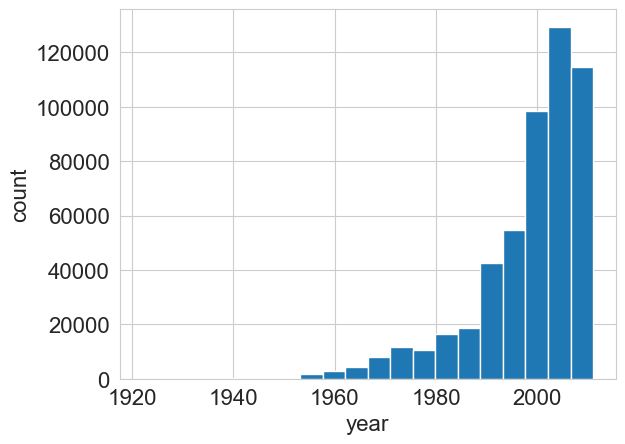

Range: 1922 - 2011
Unique values: 89


In [5]:
plt.hist(df.iloc[:, 0], bins=20)
plt.xlabel('year')
plt.ylabel('count')
plt.show()
print(f'Range: {df.iloc[:, 0].min()} - {df.iloc[:, 0].max()}')
print(f'Unique values: {np.unique(df.iloc[:, 0]).size}')

Разобьем данные на обучение и тест (не меняйте здесь ничего, чтобы сплит был одинаковым у всех).

In [6]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

train_size = int(0.75 * X.shape[0])
X_train = X[:train_size, :]
y_train = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]
X_train.shape, X_test.shape

((386508, 90), (128837, 90))

**Задание 0 (0 баллов, но при невыполнении максимальная оценка за всю работу &mdash; 0 баллов).** Мы будем использовать MSE как метрику качества. Прежде чем обучать нейронные сети, нам нужно проверить несколько простых бейзлайнов, чтобы было с чем сравнить более сложные алгоритмы. Для этого бучите `Ridge` регрессию из `sklearn`. Кроме того, посчитайте качество при наилучшем константном прогнозе.

In [7]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

ridge = Ridge().fit(X_train, y_train)
ridge_train_mse = mean_squared_error(y_train, ridge.predict(X_train))
ridge_test_mse = mean_squared_error(y_test, ridge.predict(X_test))
constant = y_train.mean()
constant_train_mse = mean_squared_error(y_train, np.full_like(y_train, constant, dtype=float))
constant_test_mse = mean_squared_error(y_test, np.full_like(y_test, constant, dtype=float))
print(f'Ridge: train={ridge_train_mse:.2f}, test={ridge_test_mse:.2f}')
print(f'Constant: train={constant_train_mse:.2f}, test={constant_test_mse:.2f}')


Ridge: train=91.67, test=89.75
Constant: train=120.11, test=117.63


Теперь приступим к экспериментам с нейросетями. Для начала отделим от данных валидацию:

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=0xE2E4)
X_train.shape, X_val.shape

((289881, 90), (96627, 90))

## Глава I. Заводим нейронную сеть (5 баллов)

**Задание 1.1 (0.5 баллов).** Заполните пропуски в функции `train_and_validate`. Она поможет нам запускать эксперименты.

In [9]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):
    """
    Plot losses and metrics while training
      - train_losses: sequence of train losses
      - train_metrics: sequence of train MSE values
      - val_losses: sequence of validation losses
      - val_metrics: sequence of validation MSE values
    """
    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label='train')
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label='val')
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label='train')
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label='val')

    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale('log')

    if max(train_metrics) / min(train_metrics) > 10:
        axs[1].set_yscale('log')

    for ax in axs:
        ax.set_xlabel('epoch')
        ax.legend()

    axs[0].set_ylabel('loss')
    axs[1].set_ylabel('MSE')
    plt.show()


def train_and_validate(model, optimizer, criterion, metric, train_loader, val_loader,
                       num_epochs, verbose=True):
    """
    Train and validate neural network
      - model: neural network (mm.Module) to train
      - optimizer: optimizer (mm.Optimizer) chained to a model
      - criterion: loss function class (mm.Criterion)
      - metrics: function to measure MSE taking neural networks predictions
                 and ground truth labels
      - train_loader: mm.DataLoader with train set
      - val_loader: mm.DataLoader with validation set
      - num_epochs: number of epochs to train
      - verbose: whether to plot metrics during training
    Returns:
      - train_mse: training MSE over the last epoch
      - val_mse: validation MSE after the last epoch
    """
    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0, 0
        pbar = tqdm(train_loader, desc=f'Training {epoch}/{num_epochs}') \
            if verbose else train_loader

        for X_batch, y_batch in pbar:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            model.backward(X_batch, criterion.backward(predictions, y_batch))
            optimizer.step()

            metric_value = metric(predictions, y_batch)
            running_loss += loss * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
            if verbose:
                pbar.set_postfix({'loss': loss, 'MSE': metric_value})

        train_losses += [running_loss / train_loader.num_samples()]
        train_metrics += [running_metric / train_loader.num_samples()]

        model.eval()
        running_loss, running_metric = 0, 0
        pbar = tqdm(val_loader, desc=f'Validating {epoch}/{num_epochs}') \
            if verbose else val_loader

        for X_batch, y_batch in pbar:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            metric_value = metric(predictions, y_batch)
            running_loss += loss * X_batch.shape[0]
            running_metric += metric_value * X_batch.shape[0]
            if verbose:
                pbar.set_postfix({'loss': loss, 'MSE': metric_value})

        val_losses += [running_loss / val_loader.num_samples()]
        val_metrics += [running_metric / val_loader.num_samples()]

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)
    
    if verbose:
        print(f'Validation MSE: {val_metrics[-1]:.3f}')
    
    return train_metrics[-1], val_metrics[-1]

**Задание 1.2 (0.75 балла).** Попробуем обучить нашу первую нейронную сеть. Здесь целевая переменная дискретная &mdash; это год выпуска песни. Поэтому будем учить сеть на классификацию.

- В качестве архитектуры сети возьмите два линейных слоя с активацией ReLU между ними c числом скрытых нейронов, равным 128.
- Используйте SGD с `lr=1e-3`.
- Возьмите размер мини-батча около 32-64, примерно 3-4 эпох обучения должно быть достаточно.
- Также преобразуйте целевую переменную так, чтобы ее значения принимали значения от $0$ до $C-1$, где $C$ &mdash; число классов (лучше передайте преобразованное значение в DataLoader, исходное нам еще пригодится)
- В качестве параметра `metric` в `train_and_validate` передайте lambda-выражение, которое считает MSE по выходу нейронной сети и целевой переменной. В случае классификации предсказывается класс с наибольшей вероятностью (или, что то же самое, с наибольшим значением логита).

In [10]:
year_min = int(y_train.min())
num_classes = int(y_train.max() - year_min + 1)
class_train_loader = mm.DataLoader(X_train, y_train - year_min, batch_size=64, shuffle=True)
class_val_loader = mm.DataLoader(X_val, y_val - year_min, batch_size=64)
class_model = mm.Sequential(mm.Linear(X_train.shape[1], 128), mm.ReLU(), mm.Linear(128, num_classes))
class_optimizer = mm.SGD(class_model, lr=1e-3)
class_train_mse, class_val_mse = train_and_validate(
    class_model, class_optimizer, mm.CrossEntropyLoss(),
    lambda logits, labels: mean_squared_error(logits.argmax(axis=1), labels),
    class_train_loader, class_val_loader, num_epochs=3, verbose=False
)
print(f'Classification MSE: train={class_train_mse:.2f}, val={class_val_mse:.2f}')
ridge_val_mse = mean_squared_error(y_val, Ridge().fit(X_train, y_train).predict(X_val))
print(f'Ridge validation MSE: {ridge_val_mse:.2f}')


Classification MSE: train=194.33, val=195.32
Ridge validation MSE: 92.13


**Задание 1.3. Ответ:** Нет: в запуске классификатор получил MSE 195.32 на валидации против 92.13 у Ridge, обученного на той же обучающей части. Кросс-энтропия считает соседние годы разными классами и не использует расстояние между ними, хотя MSE сильно зависит от величины ошибки в годах.


**Задание 1.4 (0.75 балла).** Теперь попробуем решать задачу как регрессию. Обучите нейронную сеть на MSE.

- Используйте такие же гиперпараметры обучения.
- Когда передаете целевую переменную в DataLoader, сделайте reshape в (-1, 1).
- Не забудьте изменить lambda-выражение, которые вы передаете в `train_and_validate`.
- Если что-то пойдет не так, можете попробовать меньшие значения `lr`.

In [11]:
reg_train_loader = mm.DataLoader(X_train, y_train.reshape(-1, 1), batch_size=64, shuffle=True)
reg_val_loader = mm.DataLoader(X_val, y_val.reshape(-1, 1), batch_size=64)
raw_regression_results = {}
for lr in (1e-3, 1e-6):
    model = mm.Sequential(mm.Linear(X_train.shape[1], 128), mm.ReLU(), mm.Linear(128, 1))
    optimizer = mm.SGD(model, lr=lr)
    try:
        with np.errstate(over='ignore', invalid='ignore'):
            raw_regression_results[lr] = train_and_validate(
                model, optimizer, mm.MSELoss(), mean_squared_error,
                reg_train_loader, reg_val_loader, num_epochs=3, verbose=False
            )
    except ValueError:  # non-finite predictions after divergence
        raw_regression_results[lr] = (np.nan, np.nan)
    print(f'Raw regression lr={lr:g}: train={raw_regression_results[lr][0]:.2f}, '
          f'val={raw_regression_results[lr][1]:.2f}')


Raw regression lr=0.001: train=nan, val=nan


Raw regression lr=1e-06: train=3984111.49, val=3805613.06


**Задание 1.5. Ответ:** При `lr=1e-3` обучение регрессии разошлось (нечисловые предсказания). При `lr=1e-6` оно оставалось конечным, но MSE на валидации составила около 3.78 млн — намного хуже классификатора (195.32). Сеть начинает с выходов около нуля, тогда как целевой год около 2000; без нормализации ошибки и градиенты слишком велики, а очень малый шаг замедляет обучение. Здесь замена классификации на такую регрессию не помогла.


**Задание 1.6 (0.75 балла).** Начнем с того, что попробуем отнормировать целевую переменную. Для этого воспользуемся min-max нормализацией, чтобы целевая переменная принимала значения от 0 до 1. Реализуйте функции `normalize` и `denormalize`, которые, соответственно, нормируют целевую переменную и применяют обратное преобразование. Минимум и максимум оцените по обучающей выборке (то есть эти константы должны быть фиксированными и не зависеть от передаваемой выборки).

In [12]:
target_min, target_max = y_train.min(), y_train.max()
target_range = target_max - target_min

def normalize(sample):
    """Scale years using only training-set limits."""
    return (sample - target_min) / target_range

def denormalize(sample):
    """Return normalized values to year units."""
    return sample * target_range + target_min


Теперь повторите эксперимент из **задания 1.4**, обучаясь на нормированной целевой переменной. Сделаем также еще одно изменение: добавим сигмоидную активацию после последнего линейного слоя сети. Таким образом мы гарантируем, что нейронная сеть предсказывает числа из промежутка $[0, 1]$. Использование активации - довольно распространенный прием, когда мы хотим получить числа из определенного диапазона значений. 

In [13]:
norm_train_loader = mm.DataLoader(X_train, normalize(y_train).reshape(-1, 1), batch_size=64, shuffle=True)
norm_val_loader = mm.DataLoader(X_val, normalize(y_val).reshape(-1, 1), batch_size=64)
norm_model = mm.Sequential(mm.Linear(X_train.shape[1], 128), mm.ReLU(), mm.Linear(128, 1), mm.Sigmoid())
norm_optimizer = mm.SGD(norm_model, lr=1e-3)
year_mse = lambda pred, labels: mean_squared_error(denormalize(pred), denormalize(labels))
norm_train_mse, norm_val_mse = train_and_validate(
    norm_model, norm_optimizer, mm.MSELoss(), year_mse,
    norm_train_loader, norm_val_loader, num_epochs=3, verbose=False
)
print(f'Normalized-target regression: train={norm_train_mse:.2f}, val={norm_val_mse:.2f}')


Normalized-target regression: train=279.49, val=280.14


**Задание 1.7. Ответ:** Нормализация целевого года и сигмоида снизили MSE на валидации примерно с 3.78 млн (сырая регрессия с малым шагом) до 280.08. Обучение стало численно устойчивым: выход ограничен интервалом `[0, 1]`, а масштаб целевой переменной соответствует масштабу выхода. Пока результат хуже классификатора (195.32) и Ridge (92.13 на той же валидационной выборке); далее проверяем нормализацию признаков.


**Задание 1.8 (0.75 балла).** На этот раз попробуем отнормировать не только целевую переменную, но и сами данные, которые подаются сети на вход. Для них будем использовать нормализацию через среднее и стандартное отклонение. Преобразуйте данные и повторите прошлый эксперимент. Скорее всего, имеет смысл увеличить число эпох обучения.

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
scaled_train_loader = mm.DataLoader(X_train_scaled, normalize(y_train).reshape(-1, 1), batch_size=64, shuffle=True)
scaled_val_loader = mm.DataLoader(X_val_scaled, normalize(y_val).reshape(-1, 1), batch_size=64)
scaled_model = mm.Sequential(mm.Linear(X_train.shape[1], 128), mm.ReLU(), mm.Linear(128, 1), mm.Sigmoid())
scaled_optimizer = mm.SGD(scaled_model, lr=1e-3)
scaled_train_mse, scaled_val_mse = train_and_validate(
    scaled_model, scaled_optimizer, mm.MSELoss(), year_mse,
    scaled_train_loader, scaled_val_loader, num_epochs=10, verbose=False
)
print(f'Scaled-input regression: train={scaled_train_mse:.2f}, val={scaled_val_mse:.2f}')


Scaled-input regression: train=110.26, val=110.88


Если вы все сделали правильно, то у вас должно было получиться качество, сравнимое с `Ridge` регрессией.

**Мораль:** как видите, нам пришлось сделать очень много хитрых телодвижений, чтобы нейронная сеть работала хотя бы так же, как и простая линейная модель. Здесь, конечно, показан совсем экстремальный случай, когда без нормализации данных нейронная сеть просто не учится. Как правило, в реальности завести нейронную сеть из коробки не очень сложно, но вот заставить ее работать на полную &mdash; куда более трудоемкая задача. Написание пайплайнов обучения нейросетевых моделей требует большой аккуратности, а дебаг часто превращается в угадайку. К счастью, очень часто на помощь приходит интуиция, и мы надеемся, что вы сможете выработать ее в течение нашего курса. Начнем с двух советов, которые стоит принять на вооружение:

- Обязательно начинаем любые эксперименты с бейзлайнов: без них мы бы не поняли, что нейронная сеть не учится в принципе.
- При постановке эксперментов старайтесь делать минимальное количество изменений за раз (в идеале одно!): только так можно понять, какие конкретно изменения влияют на результат.

## Часть 2. Улучшаем нейронную сеть

Продолжим экспериментировать с нейронной сетью, чтобы добиться еще лучшего качества. В заданиях 2.1-2.3 **запускайте эксперименты несколько раз (4-5)** с одинаковыми значениями гиперпараметров обучения, но с разными случайными инициализациями сети (достаточно просто прогнать код с инициализацией модели и ее обучением в цикле: каждый вызов конструктора инициализирует модель случайно). Для сравнения качества разных экспериментов **отрисовывайте ящики с усами (boxplot)** по этим нескольким запускам.

Задание 2.4 требует перебора гиперпараметров, в нем запускайте эксперимент по одному разу для каждого рассмотренного значения, чтобы сэкономить время.

**Задание 2.1 (1 балл).** Давайте попробуем другие оптимизаторы. Обучите нейросеть с помощью SGD+momentum и Adam. Опишите свои наблюдения и в дальнейших запусках используйте лучший оптимизатор. Для Adam обычно берут learning rate поменьше, в районе $10^{-3}$.

/var/folders/zs/1wr16vvd6y145sgrvn53nqb40000gn/T/ipykernel_11825/3879752930.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([values[:, 1] for values in optimizer_results.values()], labels=list(optimizer_results))


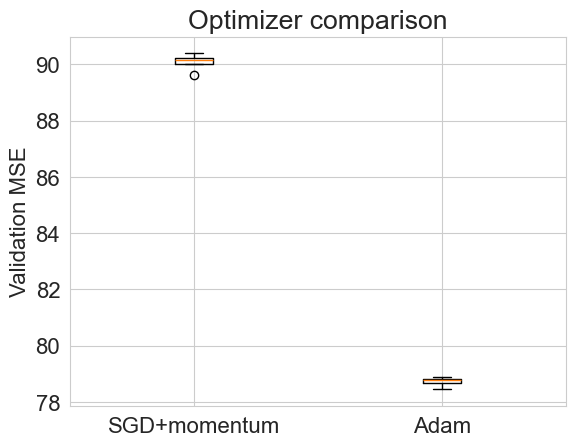

SGD+momentum: train=89.48, val=90.08 ± 0.28
Adam: train=74.93, val=78.72 ± 0.17
Better validation optimizer: Adam


In [15]:
def make_model(width=128, depth=1, regularizer=None, input_dim=None):
    in_features = X_train_scaled.shape[1] if input_dim is None else input_dim
    layers = []
    for _ in range(depth):
        layers.append(mm.Linear(in_features, width))
        if regularizer == 'batchnorm':
            layers.append(mm.BatchNormalization(width))
        if regularizer == 'dropout':
            layers.append(mm.Dropout(0.2))
        layers.append(mm.ReLU())
        in_features = width
    return mm.Sequential(*layers, mm.Linear(in_features, 1), mm.Sigmoid())

compare_train_loader = mm.DataLoader(X_train_scaled, normalize(y_train).reshape(-1, 1), batch_size=512, shuffle=True)
compare_val_loader = mm.DataLoader(X_val_scaled, normalize(y_val).reshape(-1, 1), batch_size=512)

def run_trials(spec, optimizer_name, lr, weight_decay=0, repeats=4, epochs=8):
    results = []
    for run in range(repeats):
        np.random.seed(2026 + run)
        model = make_model(**spec)
        optimizer = (mm.Adam(model, lr=lr, weight_decay=weight_decay)
                     if optimizer_name == 'Adam' else
                     mm.SGD(model, lr=lr, momentum=0.9, weight_decay=weight_decay))
        results.append(train_and_validate(model, optimizer, mm.MSELoss(), year_mse,
                                          compare_train_loader, compare_val_loader,
                                          num_epochs=epochs, verbose=False))
    return np.asarray(results)

optimizer_lrs = {'SGD+momentum': 1e-2, 'Adam': 1e-3}
optimizer_results = {name: run_trials({}, name, lr) for name, lr in optimizer_lrs.items()}
plt.boxplot([values[:, 1] for values in optimizer_results.values()], labels=list(optimizer_results))
plt.ylabel('Validation MSE'); plt.title('Optimizer comparison'); plt.show()
for name, values in optimizer_results.items():
    print(f'{name}: train={values[:, 0].mean():.2f}, val={values[:, 1].mean():.2f} ± {values[:, 1].std():.2f}')
best_optimizer = min(optimizer_results, key=lambda name: optimizer_results[name][:, 1].mean())
print(f'Better validation optimizer: {best_optimizer}')


**Задание 2.2 (1 балл).** Теперь сделаем нашу нейронную сеть более сложной. Попробуйте сделать сеть:

- более широкой (то есть увеличить размерность скрытого слоя, например, вдвое)
- более глубокой (то есть добавить еще один скрытый слой)

Опишите, как увеличение числа параметров модели влияет на качество на обучающей и валидационной выборках.

/var/folders/zs/1wr16vvd6y145sgrvn53nqb40000gn/T/ipykernel_11825/4238715467.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot([values[:, column] for values in architecture_results.values()],
/var/folders/zs/1wr16vvd6y145sgrvn53nqb40000gn/T/ipykernel_11825/4238715467.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot([values[:, column] for values in architecture_results.values()],


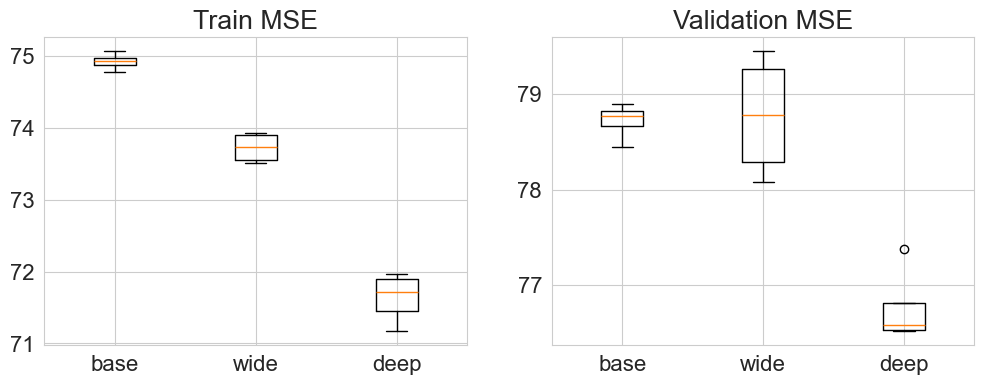

base: train=74.93, val=78.72, gap=3.80
wide: train=73.73, val=78.78, gap=5.05
deep: train=71.64, val=76.77, gap=5.12
Best validation architecture: deep


In [16]:
architecture_specs = {
    'base': {'width': 128, 'depth': 1},
    'wide': {'width': 256, 'depth': 1},
    'deep': {'width': 128, 'depth': 2},
}
architecture_results = {
    name: run_trials(spec, best_optimizer, optimizer_lrs[best_optimizer])
    for name, spec in architecture_specs.items()
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, column, title in zip(axes, (0, 1), ('Train MSE', 'Validation MSE')):
    axis.boxplot([values[:, column] for values in architecture_results.values()],
                 labels=list(architecture_results))
    axis.set_title(title)
plt.show()
for name, values in architecture_results.items():
    print(f'{name}: train={values[:, 0].mean():.2f}, val={values[:, 1].mean():.2f}, '
          f'gap={(values[:, 1] - values[:, 0]).mean():.2f}')
best_architecture = min(architecture_results, key=lambda name: architecture_results[name][:, 1].mean())
best_arch_spec = architecture_specs[best_architecture]
print(f'Best validation architecture: {best_architecture}')


**Задание 2.3 (1 балл).** Как вы должны были заметить, более сложная модель стала сильнее переобучаться. Попробуем разные методы регуляризации, чтобы бороться с переобучением. Проведите два эксперимента:

- Добавьте слой дропаута с параметром $p=0.2$ после каждого линейного слоя, кроме последнего.
- Попробуйте batch-нормализацию вместо дропаута. Строго говоря, batch-нормализация не является методом регуляризации, но никто не запрещает нам экспериментировать с ней.

Опишите результаты экспериментов. 

/var/folders/zs/1wr16vvd6y145sgrvn53nqb40000gn/T/ipykernel_11825/4209952652.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([values[:, 1] for values in regularization_results.values()],


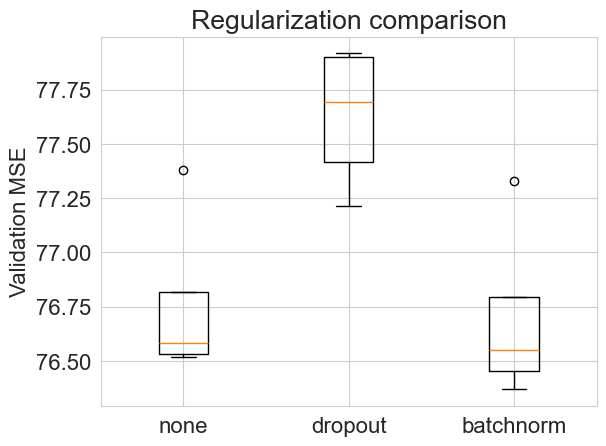

none: train=71.64, val=76.77, gap=5.12
dropout: train=78.04, val=77.63, gap=-0.41
batchnorm: train=70.30, val=76.70, gap=6.40
Best validation regularizer: batchnorm


In [17]:
regularization_results = {
    name: run_trials({**best_arch_spec, 'regularizer': None if name == 'none' else name},
                     best_optimizer, optimizer_lrs[best_optimizer])
    for name in ('none', 'dropout', 'batchnorm')
}
plt.boxplot([values[:, 1] for values in regularization_results.values()],
            labels=list(regularization_results))
plt.ylabel('Validation MSE'); plt.title('Regularization comparison'); plt.show()
for name, values in regularization_results.items():
    print(f'{name}: train={values[:, 0].mean():.2f}, val={values[:, 1].mean():.2f}, '
          f'gap={(values[:, 1] - values[:, 0]).mean():.2f}')
best_regularizer = min(regularization_results,
                       key=lambda name: regularization_results[name][:, 1].mean())
print(f'Best validation regularizer: {best_regularizer}')


**Задание 2.4 (1.5 балла).** Теперь, когда мы определились с выбором архитектуры нейронной сети, пора заняться рутиной DL-инженера &mdash; перебором гиперпараметров. Подберите оптимальное значение lr по значению MSE на валидации (по логарифмической сетке, достаточно посмотреть 3-4 значения), можете воспользоваться `verbose=False` в функции `train_and_validate`. Затем подберите оптимальное значение weight decay для данного lr (тоже по логарифмической сетке, типичные значения этого параметра лежат в диапазоне $[10^{-6}, 10^{-3}]$, но не забудьте включить нулевое значение в сетку). Постройте графики зависимости MSE на трейне и на валидации от значений параметров. Прокомментируйте получившиеся зависимости.

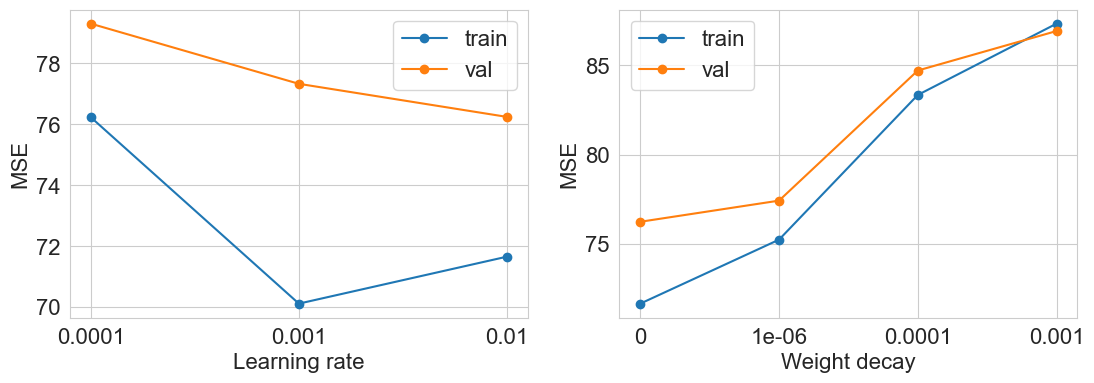

LR results: {0.0001: (76.23, 79.3), 0.001: (70.11, 77.33), 0.01: (71.66, 76.24)}
Weight-decay results: {0: (71.66, 76.24), 1e-06: (75.24, 77.43), 0.0001: (83.35, 84.72), 0.001: (87.35, 86.93)}
Best: lr=0.01, weight_decay=0


In [18]:
selected_spec = {**best_arch_spec, 'regularizer': None if best_regularizer == 'none' else best_regularizer}
lr_grid = (1e-4, 1e-3, 1e-2) if best_optimizer == 'Adam' else (1e-4, 1e-3, 1e-2)
lr_results = {lr: run_trials(selected_spec, best_optimizer, lr, repeats=1)[0] for lr in lr_grid}
best_lr = min(lr_results, key=lambda lr: lr_results[lr][1] if np.isfinite(lr_results[lr][1]) else np.inf)
wd_grid = (0, 1e-6, 1e-4, 1e-3)
wd_results = {wd: run_trials(selected_spec, best_optimizer, best_lr,
                             weight_decay=wd, repeats=1)[0] for wd in wd_grid}
best_weight_decay = min(wd_results, key=lambda wd: wd_results[wd][1]
                        if np.isfinite(wd_results[wd][1]) else np.inf)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for axis, grid, results, title in ((axes[0], lr_grid, lr_results, 'Learning rate'),
                                   (axes[1], wd_grid, wd_results, 'Weight decay')):
    axis.plot(range(len(grid)), [results[value][0] for value in grid], marker='o', label='train')
    axis.plot(range(len(grid)), [results[value][1] for value in grid], marker='o', label='val')
    axis.set_xticks(range(len(grid)), [f'{value:g}' for value in grid])
    axis.set_xlabel(title); axis.set_ylabel('MSE'); axis.legend()
plt.show()
print('LR results:', {lr: tuple(np.round(result, 2)) for lr, result in lr_results.items()})
print('Weight-decay results:', {wd: tuple(np.round(result, 2)) for wd, result in wd_results.items()})
print(f'Best: lr={best_lr:g}, weight_decay={best_weight_decay:g}')


Как вы могли заметить, еще одна рутина DL-инженера &mdash; утомительное ожидание обучения моделей.

**Задание 2.5 (0.5 балла).** Мы провели большое число экспериментов и подобрали оптимальную архитектуру и гиперпараметры. Пришло время обучить модель на полной обучающей выборке, померять качество на тестовой выборке и сравнить с бейзлайнами. Проделайте это. 

In [19]:
X_full = np.concatenate((X_train, X_val))
y_full = np.concatenate((y_train, y_val))
final_scaler = StandardScaler().fit(X_full)
full_min, full_range = y_full.min(), y_full.max() - y_full.min()
full_normalize = lambda years: (years - full_min) / full_range
full_denormalize = lambda values: values * full_range + full_min
final_train_loader = mm.DataLoader(final_scaler.transform(X_full), full_normalize(y_full).reshape(-1, 1),
                                   batch_size=512, shuffle=True)
final_test_loader = mm.DataLoader(final_scaler.transform(X_test), full_normalize(y_test).reshape(-1, 1),
                                  batch_size=512)
np.random.seed(2026)
final_model = make_model(**selected_spec)
final_optimizer = (mm.Adam(final_model, lr=best_lr, weight_decay=best_weight_decay)
                   if best_optimizer == 'Adam' else
                   mm.SGD(final_model, lr=best_lr, momentum=0.9, weight_decay=best_weight_decay))
final_loss = mm.MSELoss()
for _ in range(8):
    final_model.train()
    for X_batch, y_batch in final_train_loader:
        final_optimizer.zero_grad()
        prediction = final_model(X_batch)
        final_model.backward(X_batch, final_loss.backward(prediction, y_batch))
        final_optimizer.step()
final_model.eval()
def final_mse(loader):
    squared_error = 0.0
    for X_batch, y_batch in loader:
        error = full_denormalize(final_model(X_batch)) - full_denormalize(y_batch)
        squared_error += np.square(error).sum()
    return squared_error / loader.num_samples()

print(f'Final network: train MSE={final_mse(final_train_loader):.2f}, '
      f'test MSE={final_mse(final_test_loader):.2f}')
print(f'Baselines on test: Ridge={ridge_test_mse:.2f}, constant={constant_test_mse:.2f}')


Final network: train MSE=69.32, test MSE=75.19
Baselines on test: Ridge=89.75, constant=117.63


### Результаты полного запуска

Все значения ниже — MSE в исходной шкале года. Для сравнений 2.1–2.3 использованы 4 запуска по 8 эпох; для перебора 2.4 — 1 запуск на конфигурацию.

| Эксперимент | Валидационная MSE |
|---|---:|
| 2.1: SGD + momentum / Adam | 90.08 / 78.72 |
| 2.2: базовая / широкая / глубокая сеть | 78.72 / 78.78 / 76.77 |
| 2.3: без регуляризации / dropout / batch normalization | 76.77 / 77.63 / 76.70 |
| 2.4: Adam, batch normalization, lr=0.01, weight decay=0 | 76.24 |

Выбраны Adam, глубокая сеть с двумя скрытыми слоями по 128 нейронов и batch normalization. После обучения на объединённых обучающей и валидационной выборках тестовая MSE составила **75.19**. Для сравнения, Ridge получил **89.75**, а константный прогноз — **117.63**.
